# Previsão de Propensão de Compra de Carros com XGBoost

## Objetivo

O principal objetivo é construir um modelo preditivo robusto e eficaz que possa auxiliar empresas a otimizar suas estratégias de marketing e vendas, direcionando recursos para clientes com maior probabilidade de conversão.

In [1]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
base = pd.read_csv('CARRO_CLIENTES.csv')

In [3]:
# Verificando base
base.head()

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


In [4]:
# Traduzindo colunas para o portugues para facilitar as analises
base = base.rename(columns={'User ID':'id', 'Gender':'genero', 'Age':'idade', 'AnnualSalary':'salario', 'Purchased':'comprou'})

In [5]:
# Verificando tipo de dados
base.info()
base.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       1000 non-null   int64 
 1   genero   1000 non-null   object
 2   idade    1000 non-null   int64 
 3   salario  1000 non-null   int64 
 4   comprou  1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


,id,genero,idade,salario,comprou
count,1000.000000,1000,1000.000000,1000.000000,1000.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,516,NaN,NaN,NaN
mean,500.500000,NaN,40.106000,72689.000000,0.402000
std,288.819436,NaN,10.707073,34488.341867,0.490547
min,1.000000,NaN,18.000000,15000.000000,0.000000
25%,250.750000,NaN,32.000000,46375.000000,0.000000
50%,500.500000,NaN,40.000000,72000.000000,0.000000
75%,750.250000,NaN,48.000000,90000.000000,1.000000


In [6]:
# Verificando de valores ausentes
base.isnull().sum()

,0
id,0
genero,0
idade,0
salario,0
comprou,0


In [7]:
# Verificando Duplicatas
base.duplicated().sum()

np.int64(0)

Com base na análise, **não** foi identificado **valores ausentes e Duplicatas**.

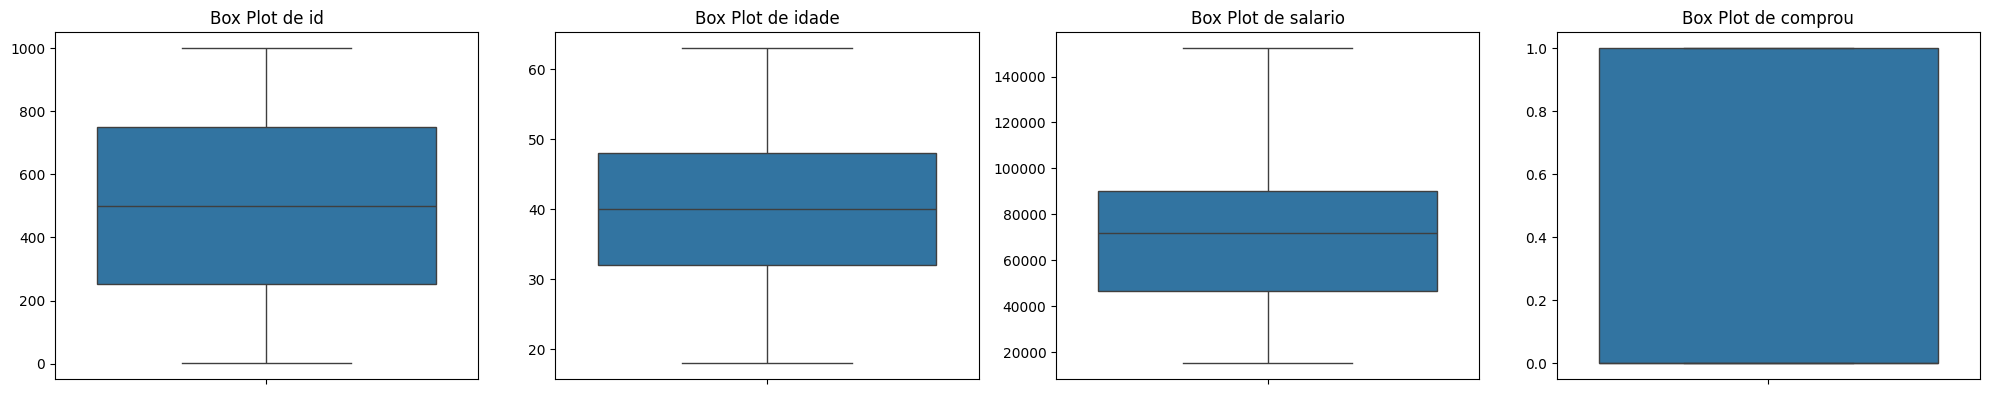

In [8]:
# Selecionando apenas as colunas numéricas para o box plot
colunas_numericas = base.select_dtypes(include=['int64', 'float64'])

# Plotando BoxPlot
plt.figure(figsize=(20, 15))
for i, col in enumerate(colunas_numericas.columns):
    plt.subplot(4, 4, i + 1) # Ajuste o layout conforme o número de colunas
    sns.boxplot(y=base[col])
    plt.title(f'Box Plot de {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### Análise dos box plots:
Não foi identificada a presença de **outliers** significativos nas colunas numéricas, sugerindo que os dados estão dentro de uma distribuição esperada e não contêm valores extremos que possam distorcer a análise subsequente.

In [9]:
# Excluindo a coluna 'id'
base = base.drop('id', axis=1)

In [10]:
base.head()

,genero,idade,salario,comprou
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0


In [11]:
# Aplicando Label Encoder para a coluna 'genero' e dropando coluna categorica da base
label_encoder = LabelEncoder()
base['genero'] = label_encoder.fit_transform(base['genero'])
base.drop('genero', axis=1, inplace=True)
base.head()

,idade,salario,comprou
0,35,20000,0
1,40,43500,0
2,49,74000,0
3,40,107500,1
4,25,79000,0


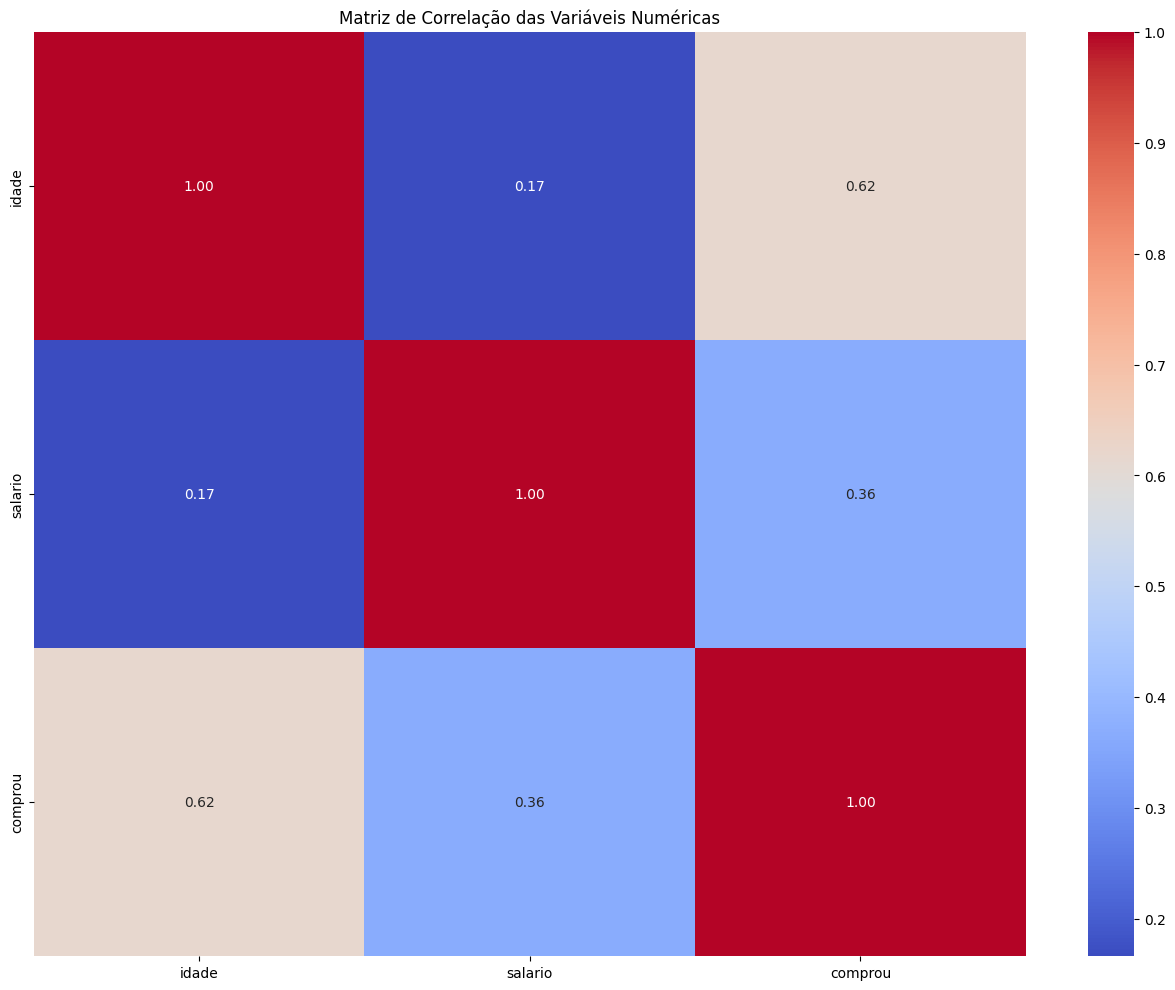

Matriz de Correlação das Variáveis Numéricas:
            idade   salario   comprou
idade    1.000000  0.166042  0.616036
salario  0.166042  1.000000  0.364974
comprou  0.616036  0.364974  1.000000


In [12]:
# Selecionar apenas as colunas numéricas para a matriz de correlação
numerical_cols = base.select_dtypes(include=['int64', 'float64']).columns

# Calcular a matriz de correlação
correlation_matrix = base[numerical_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

print("Matriz de Correlação das Variáveis Numéricas:")
print(correlation_matrix)

### Com base na matriz de correlação, podemos analisar o seguinte:

* **Idade e Compra:** Há uma correlação positiva moderadamente forte de aproximadamente 0.62. Isso sugere que, conforme a idade aumenta, a probabilidade de um cliente comprar um carro também aumenta significativamente.
* **Salário Anual e Compra:** Há uma correlação positiva mais fraca, de aproximadamente 0.36. Embora ainda positiva, indica que um salário anual mais alto tem uma influência menor na decisão de compra do que a idade, mas ainda contribui para uma maior probabilidade de compra.
* **Idade e Salário Anual:** A correlação entre idade e salário é de aproximadamente 0.17, que é uma correlação positiva muito fraca. Isso indica que, embora haja uma ligeira tendência de salários aumentarem com a idade, a relação não é forte.

### Visualização da Correlação: Idade vs Compra

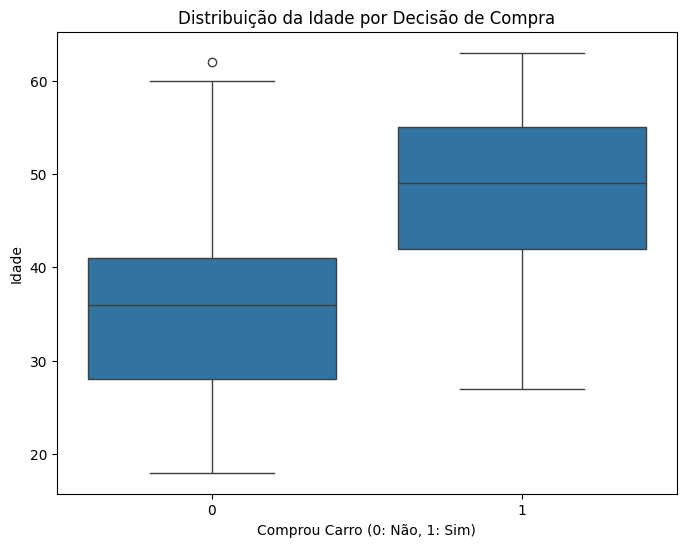

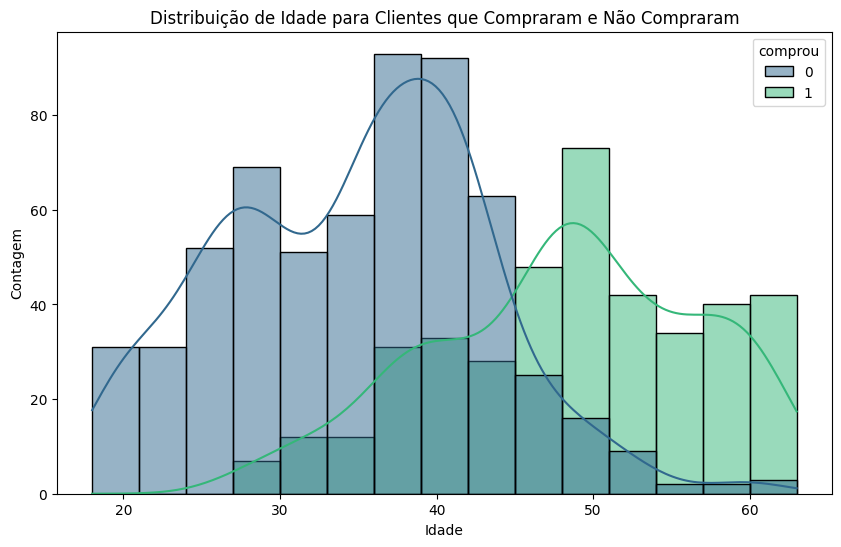

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='comprou', y='idade', data=base)
plt.title('Distribuição da Idade por Decisão de Compra')
plt.xlabel('Comprou Carro (0: Não, 1: Sim)')
plt.ylabel('Idade')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=base, x='idade', hue='comprou', kde=True, palette='viridis')
plt.title('Distribuição de Idade para Clientes que Compraram e Não Compraram')
plt.xlabel('Idade')
plt.ylabel('Contagem')
plt.show()

### Visualização da Correlação: Salário Anual vs Compra

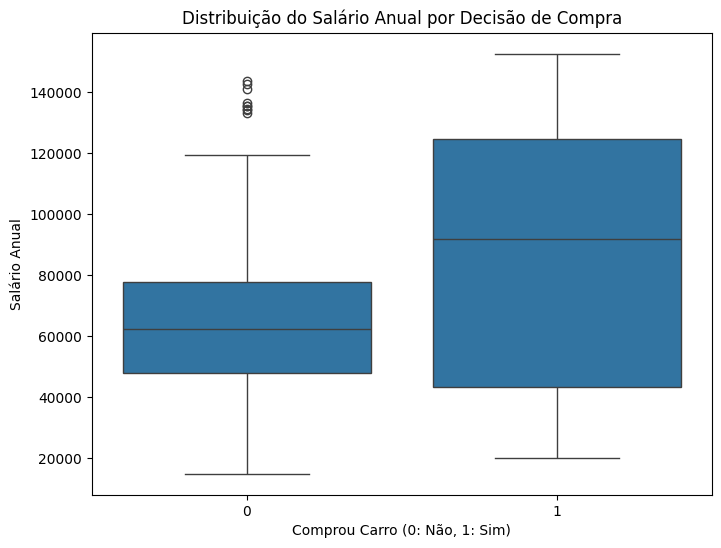

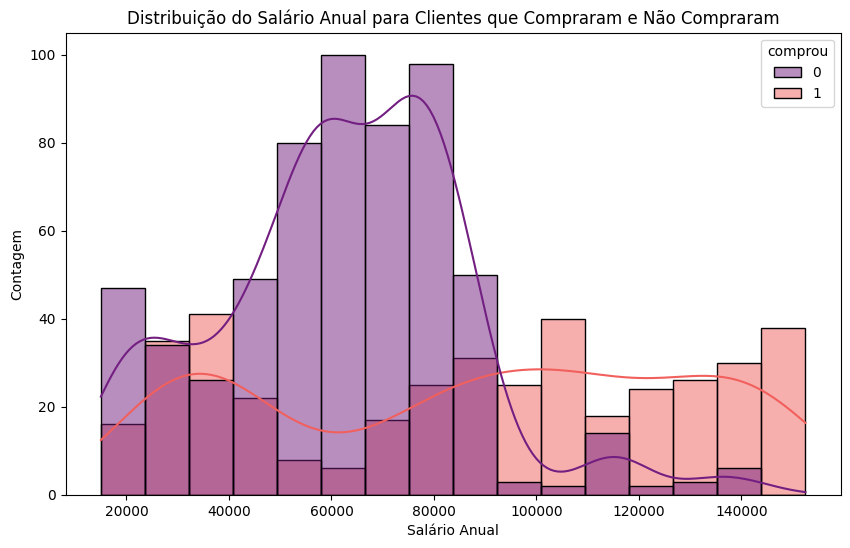

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='comprou', y='salario', data=base)
plt.title('Distribuição do Salário Anual por Decisão de Compra')
plt.xlabel('Comprou Carro (0: Não, 1: Sim)')
plt.ylabel('Salário Anual')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=base, x='salario', hue='comprou', kde=True, palette='magma')
plt.title('Distribuição do Salário Anual para Clientes que Compraram e Não Compraram')
plt.xlabel('Salário Anual')
plt.ylabel('Contagem')
plt.show()

### Análise dos Gráficos de Idade vs. Compra:
* **Box Plot da Idade por Decisão de Compra:** Fica evidente que a mediana da idade para clientes que compraram um carro (comprou = 1) é significativamente maior do que para aqueles que não compraram (comprou = 0). A distribuição da idade para quem comprou tende a ser mais alta, confirmando a forte correlação positiva que observamos na matriz.
* **Histograma da Idade para Clientes que Compraram e Não Compraram:** Este gráfico mostra que há uma maior concentração de pessoas mais jovens (abaixo de 40 anos) que não compraram o carro, enquanto a proporção de compradores aumenta consideravelmente na faixa etária mais avançada.
### Análise dos Gráficos de Salário Anual vs. Compra:
* **Box Plot do Salário Anual por Decisão de Compra:** Observamos que, em média, clientes com salários anuais mais altos têm uma tendência maior a comprar um carro. A mediana do salário é maior para o grupo que comprou, mas a diferença não é tão acentuada quanto na idade, o que também se alinha com a correlação mais fraca observada anteriormente.
* **Histograma do Salário Anual para Clientes que Compraram e Não Compraram:** Este gráfico sugere que há um maior volume de vendas em faixas salariais mais elevadas, embora a sobreposição entre os grupos seja maior do que na distribuição de idade.

### CONCLUSÃO:
* Pode se dizer que os gráficos reforçam que a **idade** é um fator preditivo mais forte para a decisão de compra do que o salário anual, mas ambos contribuem para a probabilidade de compra.

In [15]:
# Separando X (features) e Y (target)
X = base.drop('comprou', axis=1)
Y = base['comprou']

# Separando base de treino e teste
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [16]:
model_xgboost = xgb.XGBClassifier()
model_xgboost.objective

'binary:logistic'

In [17]:
model_xgboost = xgb.XGBClassifier().fit(X_train, Y_train)
model_xgboost.objective

'binary:logistic'

In [18]:
# Adicionando hiperparametros
model_xgboost_hyper = xgb.XGBClassifier(
max_depth=6,                  # Profundidade máxima da árvore
n_estimators=100,             # Número de árvores a serem construídas
)

In [19]:
model_xgboost_hyper = xgb.XGBClassifier().fit(X_train, Y_train)

In [20]:
# Realizando previsões e probabilidades
Y_pred = model_xgboost.predict(X_test)           # Previsões das classes
Y_pred_prob = model_xgboost.predict_proba(X_test)  # Probabilidades de cada classe

In [21]:
Y_pred_prob

array([[9.42999005e-01, 5.70009723e-02],
       [3.08376491e-01, 6.91623509e-01],
       [9.99828935e-01, 1.71080814e-04],
       [7.19143033e-01, 2.80856997e-01],
       [1.54224455e-01, 8.45775545e-01],
       [2.42882967e-03, 9.97571170e-01],
       [1.02925301e-03, 9.98970747e-01],
       [9.99462843e-01, 5.37175743e-04],
       [9.97811258e-01, 2.18873867e-03],
       [9.98298407e-01, 1.70159130e-03],
       [9.89693224e-01, 1.03067625e-02],
       [9.99807477e-01, 1.92523381e-04],
       [8.45319152e-01, 1.54680878e-01],
       [9.99457479e-01, 5.42494876e-04],
       [2.91711092e-03, 9.97082889e-01],
       [1.80784106e-01, 8.19215894e-01],
       [8.61192703e-01, 1.38807297e-01],
       [2.73608208e-01, 7.26391792e-01],
       [1.25194192e-02, 9.87480581e-01],
       [9.99691427e-01, 3.08594812e-04],
       [9.99203742e-01, 7.96281034e-04],
       [1.60318613e-03, 9.98396814e-01],
       [3.11853290e-02, 9.68814671e-01],
       [9.99828935e-01, 1.71080814e-04],
       [1.862442

In [22]:
# Então uma vez que temos as probabilidades, fazemos a transformação das previsões e os rótulos de volta para os rótulos originais
Y_pred_original = label_encoder.inverse_transform(Y_pred)
Y_test_original = label_encoder.inverse_transform(Y_test)

In [23]:
# Avaliando o modelo usando as previsões binárias diretas
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f'Acurácia: {accuracy}')
print('Relatório de Classificação:')
print(report)
print('Matriz de Confusão:')
print(conf_matrix)

Acurácia: 0.905
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       112
           1       0.93      0.85      0.89        88

    accuracy                           0.91       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.91      0.90       200

Matriz de Confusão:
[[106   6]
 [ 13  75]]


In [24]:
# Features mais importantes
importances = model_xgboost.get_booster().get_score(importance_type='gain')

# Convertendo o dicionário de importâncias para uma Base
importance_base = pd.DataFrame(list(importances.items()), columns=['Feature', 'Importance'])
importance_base['Importance'] = importance_base['Importance'].astype(float)
importance_base = importance_base.sort_values(by='Importance', ascending=False)

print(importance_base)

   Feature  Importance
0    idade    1.786810
1  salario    1.162221


### Conclusão Final

Neste projeto, desenvolvemos e avaliamos um modelo XGBoost para prever a propensão de compra de carros por clientes, utilizando 'idade' e 'salário anual' como características preditivas.

**Desempenho do Modelo:**

O modelo demonstrou um desempenho robusto, alcançando uma **Acurácia de 0.905** no conjunto de teste. A análise detalhada do **Relatório de Classificação** revelou:

*   Para a **Classe 0 (Não Comprou)**, o modelo apresentou alta **Recall (0.95)**, identificando a maioria dos clientes que não compraram, e boa **Precisão (0.89)**.
*   Para a **Classe 1 (Comprou)**, a **Precisão (0.93)** foi excelente, minimizando falsos positivos, enquanto o **Recall (0.85)** indicou uma boa capacidade de identificar clientes que realmente compraram.

A **Matriz de Confusão** reforça esses resultados, com:
*   **106 Verdadeiros Negativos** (clientes que não compraram e foram previstos corretamente).
*   **75 Verdadeiros Positivos** (clientes que compraram e foram previstos corretamente).
*   Apenas **6 Falsos Positivos** (previstos como compradores, mas não o foram) e **13 Falsos Negativos** (previstos como não compradores, mas o foram).

Esses indicadores demonstram que o modelo é altamente confiável e eficaz na identificação de potenciais compradores, com uma baixa taxa de erros significativos.

**Importância das Características:**

Confirmando nossa análise inicial de correlação, o modelo XGBoost identificou a **'idade'** como a característica mais influente na decisão de compra (com uma importância de 1.78), seguida pelo **'salário'** (com importância de 1.16). Isso sugere que a idade do cliente é um fator preditivo mais forte para a compra de carros do que o seu salário anual, embora ambos sejam contribuintes importantes para a probabilidade de compra.

**Em resumo, o modelo XGBoost construído é uma ferramenta valiosa e eficaz para identificar clientes com alta propensão à compra de carros, baseando-se principalmente na idade e, em menor grau, no salário anual. Sua alta precisão e recall para a classe de interesse (compra) o tornam ideal para otimizar estratégias de marketing e vendas.**